In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

# Load the data
import pandas as pd
df = pd.read_csv(next(iter(uploaded)))

# Optional: preview the data
df.head()

Saving tabletennis_clean.csv to tabletennis_clean.csv


,1st_game_-_odd/even_even,set_3_home_point,match_score_home,set_2_home_point,game_handicap_1.5_away_(-1.5),Team A,1st_game_-_total_points_over_16.5,1st_game_-_odd/even_odd,1st_game_-_1st_point_home,set_5_home_point,...,1st_game_-_point_handicap_away_(+7.5),1st_game_-_point_handicap_home_(-7.5),2nd_game_-_point_handicap_home_(+5.5),2nd_game_-_point_handicap_away_(-5.5),2nd_game_-_point_handicap_home_(-6.5),2nd_game_-_point_handicap_away_(+6.5),2nd_game_-_total_points_over_15.5,2nd_game_-_total_points_under_15.5,4th_game_-_point_handicap_away_(+5.5),4th_game_-_point_handicap_home_(-5.5)
0,0.6202,NaN,0,NaN,0.4079,"Bohac, Martin",0.757,0.3798,0.4932,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.6202,NaN,0,NaN,0.4079,"Bohac, Martin",0.757,0.3798,0.4932,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.6202,NaN,0,NaN,0.4079,"Bohac, Martin",0.757,0.3798,0.4932,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.6202,NaN,0,NaN,0.4079,"Bohac, Martin",0.757,0.3798,0.4932,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.6202,NaN,0,NaN,0.4079,"Bohac, Martin",0.757,0.3798,0.4932,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Display columns to understand the data structure
print(df.columns.tolist())

def preprocess_data(df):
  # Convert timestamp to datetime
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])

  # Sort by match ID and timestamp
  df = df.sort_values(['Match ID', 'Timestamp'])

  # Fill N/A values appropriately
  df.fillna(0, inplace=True)

  # Create target variable
  # Initialize a column with zeros
  df['home_won'] = 0

  # Get final rows for each match
  final_rows = df.groupby('Match ID').tail(1)

  # Determine if home won based on scores
  home_won_matches = final_rows[final_rows['match_score_home'] > final_rows['match_score_away']]['Match ID']

  # Set 'home_won' = 1 for those matches
  df.loc[df['Match ID'].isin(home_won_matches), 'home_won'] = 1

  # Select and organize all features (excluding team names and timestamps)
  features = [
      # ===== MATCH OUTCOME & SCORES =====
      'match_score_home', 'match_score_away',
      'winner_home', 'winner_away',  # Current probabilities

      # # ===== TOTAL POINTS MARKETS =====
      # # Main total points
      # 'total_points_over_73.5', 'total_points_under_73.5',
      # 'total_points_over_74.5', 'total_points_under_74.5',
      # 'total_points_over_75.5', 'total_points_under_75.5',

      # # Other total points variations
      # 'total_points_over_72.5', 'total_points_under_72.5',
      # 'total_points_over_76.5', 'total_points_under_76.5',
      # 'total_points_over_77.5', 'total_points_under_77.5',
      # 'total_points_over_78.5', 'total_points_under_78.5',
      # 'total_points_over_79.5', 'total_points_under_79.5',

      # # ===== POINT HANDICAP MARKETS =====
      # # Main point handicaps
      # 'point_handicap_home_(-2.5)', 'point_handicap_away_(+2.5)',
      # 'point_handicap_home_(-1.5)', 'point_handicap_away_(+1.5)',
      # 'point_handicap_home_(+0.5)', 'point_handicap_away_(-0.5)',

      # # Other point handicap variations
      # 'point_handicap_home_(-3.5)', 'point_handicap_away_(+3.5)',
      # 'point_handicap_home_(-4.5)', 'point_handicap_away_(+4.5)',
      # 'point_handicap_home_(-5.5)', 'point_handicap_away_(+5.5)',

      # # ===== GAME HANDICAP MARKETS =====
      # 'game_handicap_1.5_home_(+1.5)', 'game_handicap_1.5_away_(-1.5)',
      # 'game_handicap_-1.5_home_(-1.5)', 'game_handicap_-1.5_away_(+1.5)',
      # 'game_handicap_2.5_home_(+2.5)', 'game_handicap_2.5_away_(-2.5)',

      # ===== EXACT GAMES MARKETS =====
      'exact_games_3', 'exact_games_4', 'exact_games_5',

      # # ===== SET SCORES =====
      'set_1_home_point', 'set_1_away_point',
      'set_2_home_point', 'set_2_away_point',
      # 'set_3_home_point', 'set_3_away_point',
      # 'set_4_home_point', 'set_4_away_point',
      # 'set_5_home_point', 'set_5_away_point',

      # # ===== FIRST GAME FEATURES =====
      # Outcome
      '1st_game_-_winner_home', '1st_game_-_winner_away',

      # Point handicaps
      '1st_game_-_point_handicap_home_(-4.5)',
      '1st_game_-_point_handicap_away_(+4.5)',
      '1st_game_-_point_handicap_home_(-3.5)',
      '1st_game_-_point_handicap_away_(+3.5)',

      # Race to points
      '1st_game_-_race_to_3_points_home',
      '1st_game_-_race_to_3_points_away',

      # Total points
      '1st_game_-_total_points_over_16.5',
      '1st_game_-_total_points_under_16.5',
      '1st_game_-_total_points_over_17.5',
      '1st_game_-_total_points_under_17.5',

      # First point
      '1st_game_-_1st_point_home',
      '1st_game_-_1st_point_away',

      # # Odd/even
      # '1st_game_-_odd/even_odd',
      # '1st_game_-_odd/even_even',

      # ===== SECOND GAME FEATURES =====
      # Outcome
      '2nd_game_-_winner_home', '2nd_game_-_winner_away',

      # Point handicaps
      '2nd_game_-_point_handicap_home_(-2.5)',
      '2nd_game_-_point_handicap_away_(+2.5)',
      '2nd_game_-_point_handicap_home_(-3.5)',
      '2nd_game_-_point_handicap_away_(+3.5)',

      # Race to points
      '2nd_game_-_race_to_3_points_home',
      '2nd_game_-_race_to_3_points_away',

      # Total points
      '2nd_game_-_total_points_over_16.5',
      '2nd_game_-_total_points_under_16.5',
      '2nd_game_-_total_points_over_17.5',
      '2nd_game_-_total_points_under_17.5',

      # # Odd/even
      # '2nd_game_-_odd/even_odd',
      # '2nd_game_-_odd/even_even',

      # # ===== THIRD GAME FEATURES =====
      # # Outcome
      # '3rd_game_-_winner_home', '3rd_game_-_winner_away',

      # # Point handicaps
      # '3rd_game_-_point_handicap_home_(-2.5)',
      # '3rd_game_-_point_handicap_away_(+2.5)',
      # '3rd_game_-_point_handicap_home_(-3.5)',
      # '3rd_game_-_point_handicap_away_(+3.5)',

      # # Race to points
      # '3rd_game_-_race_to_3_points_home',
      # '3rd_game_-_race_to_3_points_away',

      # # Total points
      # '3rd_game_-_total_points_over_16.5',
      # '3rd_game_-_total_points_under_16.5',
      # '3rd_game_-_total_points_over_17.5',
      # '3rd_game_-_total_points_under_17.5',

      # # Odd/even
      # '3rd_game_-_odd/even_odd',
      # '3rd_game_-_odd/even_even',

      # # ===== FOURTH GAME FEATURES =====
      # # Outcome
      # '4th_game_-_winner_home', '4th_game_-_winner_away',

      # # Point handicaps
      # '4th_game_-_point_handicap_home_(-2.5)',
      # '4th_game_-_point_handicap_away_(+2.5)',
      # '4th_game_-_point_handicap_home_(-3.5)',
      # '4th_game_-_point_handicap_away_(+3.5)',

      # # Race to points
      # '4th_game_-_race_to_3_points_home',
      # '4th_game_-_race_to_3_points_away',

      # # Total points
      # '4th_game_-_total_points_over_16.5',
      # '4th_game_-_total_points_under_16.5',
      # '4th_game_-_total_points_over_17.5',
      # '4th_game_-_total_points_under_17.5',

      # # Odd/even
      # '4th_game_-_odd/even_odd',
      # '4th_game_-_odd/even_even',

      # # ===== FIFTH GAME FEATURES =====
      # '5th_game_-_winner_home', '5th_game_-_winner_away',

  ]


  sequence_length = 200
  X, y, match_info = [], [], []

  for match_id in df['Match ID'].unique():
      match_data = df[df['Match ID'] == match_id]
      if len(match_data) >= sequence_length:
          # Take the most recent sequence
          X.append(match_data[features].iloc[-sequence_length:].values)
          y.append(match_data['home_won'].iloc[-1])
          # Store match info (ID, teams, and last timestamp)
          match_info.append({
              'match_id': match_id,
              'team_a': match_data['Team A'].iloc[0],
              'team_b': match_data['Team B'].iloc[0],
              'last_timestamp': match_data['Timestamp'].iloc[-1]
          })

  X = np.array(X)
  y = np.array(y)
  match_info = pd.DataFrame(match_info)

  return X, y, features, match_info

['1st_game_-_odd/even_even', 'set_3_home_point', 'match_score_home', 'set_2_home_point', 'game_handicap_1.5_away_(-1.5)', 'Team A', '1st_game_-_total_points_over_16.5', '1st_game_-_odd/even_odd', '1st_game_-_1st_point_home', 'set_5_home_point', 'Timestamp', 'total_points_over_73.5', 'set_4_home_point', '1st_game_-_total_points_under_16.5', 'Match ID', 'total_points_under_73.5', 'point_handicap_away_(-2.5)', 'set_2_away_point', 'game_handicap_1.5_home_(+1.5)', 'set_5_away_point', 'Team B', 'set_1_home_point', '1st_game_-_point_handicap_home_(-3.5)', '1st_game_-_race_to_3_points_home', 'match_finished', 'set_4_away_point', 'match_score_away', '1st_game_-_point_handicap_away_(+3.5)', 'set_3_away_point', '1st_game_-_1st_point_away', 'exact_games_5', 'point_handicap_home_(+2.5)', 'exact_games_3', 'Start Time', 'exact_games_4', '1st_game_-_race_to_3_points_away', 'set_1_away_point', '1st_game_-_winner_home', 'winner_away', '1st_game_-_total_points_over_17.5', '1st_game_-_winner_away', '1st_g

In [ ]:
# Preprocess data (now returns match_info)
X, y, features, match_info = preprocess_data(df)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Convert the first sequence in X to a DataFrame
first_sequence_df = pd.DataFrame(X[0], columns=features)

# Display it
print("First X sequence as DataFrame:")
display(first_sequence_df)

# Show corresponding labels
print("y_winner[0]:", y[0])

X shape: (26, 200, 37)
y shape: (26,)
First X sequence as DataFrame:


,match_score_home,match_score_away,winner_home,winner_away,exact_games_3,exact_games_4,exact_games_5,set_1_home_point,set_1_away_point,set_2_home_point,...,2nd_game_-_point_handicap_home_(-2.5),2nd_game_-_point_handicap_away_(+2.5),2nd_game_-_point_handicap_home_(-3.5),2nd_game_-_point_handicap_away_(+3.5),2nd_game_-_race_to_3_points_home,2nd_game_-_race_to_3_points_away,2nd_game_-_total_points_over_16.5,2nd_game_-_total_points_under_16.5,2nd_game_-_total_points_over_17.5,2nd_game_-_total_points_under_17.5
0,0.0,1.0,0.2632,0.7368,0.2759,0.4138,0.3103,7.0,11.0,2.0,...,0.4267,0.5733,0.0,0.0,0.0,0.0,0.7692,0.2308,0.000,0.000
1,0.0,1.0,0.2308,0.7692,0.3324,0.3842,0.2834,7.0,11.0,2.0,...,0.3415,0.6585,0.0,0.0,0.0,0.0,0.0000,0.0000,0.686,0.314
2,0.0,1.0,0.2308,0.7692,0.3324,0.3842,0.2834,7.0,11.0,2.0,...,0.3415,0.6585,0.0,0.0,0.0,0.0,0.0000,0.0000,0.686,0.314
3,0.0,1.0,0.2308,0.7692,0.3324,0.3842,0.2834,7.0,11.0,2.0,...,0.3415,0.6585,0.0,0.0,0.0,0.0,0.0000,0.0000,0.686,0.314
4,0.0,1.0,0.2308,0.7692,0.3324,0.3842,0.2834,7.0,11.0,2.0,...,0.3415,0.6585,0.0,0.0,0.0,0.0,0.0000,0.0000,0.686,0.314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.0,2.0,0.1053,0.8947,0.5547,0.2809,0.1643,7.0,11.0,7.0,...,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000,0.000
196,0.0,2.0,0.1053,0.8947,0.5547,0.2809,0.1643,7.0,11.0,7.0,...,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000,0.000
197,0.0,2.0,0.1053,0.8947,0.5547,0.2809,0.1643,7.0,11.0,7.0,...,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000,0.000
198,0.0,2.0,0.1053,0.8947,0.5547,0.2809,0.1643,7.0,11.0,7.0,...,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000,0.000


y_winner[0]: 0


In [ ]:
# Split data while preserving match info
def split_data_with_info(X, y, match_info, test_size=0.2, val_size=0.125, random_state=42):
    # First split (test vs train+val)
    train_val_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=test_size,
        random_state=random_state
    )

    # Second split (train vs val)
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_size/(1-test_size),
        random_state=random_state
    )

    # Split features and labels
    X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
    y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

    # Split match info
    train_info = match_info.iloc[train_idx]
    val_info = match_info.iloc[val_idx]
    test_info = match_info.iloc[test_idx]

    return (X_train, X_val, X_test,
            y_train, y_val, y_test,
            train_info, val_info, test_info)

# Perform the split
(X_train, X_val, X_test,
 y_train, y_val, y_test,
 train_info, val_info, test_info) = split_data_with_info(X, y, match_info)

In [ ]:
# Print match information for each split
def print_split_info(info_df, split_name):
    print(f"\n{split_name.upper()} SET ({len(info_df)} matches)")
    print("="*60)
    print(info_df[['match_id', 'team_a', 'team_b', 'last_timestamp']])
    print("="*60)

print_split_info(train_info, "Training")
print_split_info(val_info, "Validation")
print_split_info(test_info, "Test")

# Normalize data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)


TRAINING SET (16 matches)
    match_id                  team_a               team_b  \
4   59969971         Sinicki, Maciej     Baran, Sebastian   
12  59993621  Havel, Ladislav (1956)        Regner, Tomas   
22  59997569         Olejnik, Martin         Braun, Josef   
5   59969991     Marchlewski, Marcin     Mlynarski, Filip   
19  59993787        Vavrecka, Michal  Petracek, Vratislav   
10  59986709          Kulveit, Jonas         Vonasek, Jan   
25  60001093        Koutnik, Vojtech        Vojna, Daniel   
23  60000159             Holas, Petr      Hromadka, Pavol   
21  59997551       Przewlocki, Piotr     Morawiec, Daniel   
6   59986647            Sulc, Martin         Vonasek, Jan   
2   59969895          Idaczyk, Rafal   Szostok, Sebastian   
18  59993725     Beran, Tomas (2000)        Polak, Ondrej   
3   59969899         Misiak, Mateusz       Eliasz, Adrian   
17  59993687         Lubas, Miloslav       Berdych, Pavel   
20  59997543     Marchlewski, Kacper      Sinicki, Maciej 

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.2500 - loss: 0.7125 - val_accuracy: 1.0000 - val_loss: 0.6727
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step - accuracy: 0.5000 - loss: 0.6850 - val_accuracy: 1.0000 - val_loss: 0.6463
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step - accuracy: 0.5625 - loss: 0.6582 - val_accuracy: 1.0000 - val_loss: 0.6143
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step - accuracy: 0.6250 - loss: 0.6336 - val_accuracy: 1.0000 - val_loss: 0.5809
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step - accuracy: 0.7500 - loss: 0.6035 - val_accuracy: 1.0000 - val_loss: 0.5450
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step - accuracy: 0.6875 - loss: 0.5845 - val_accuracy: 1.0000 - val_loss: 0.5193
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6875 - loss: 0.5734 - val_accuracy: 1.0000 - val_loss: 0.5041
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7500 - loss: 0.5509 - val_accuracy: 0.7500 - val_loss: 0.4950
Epoch 

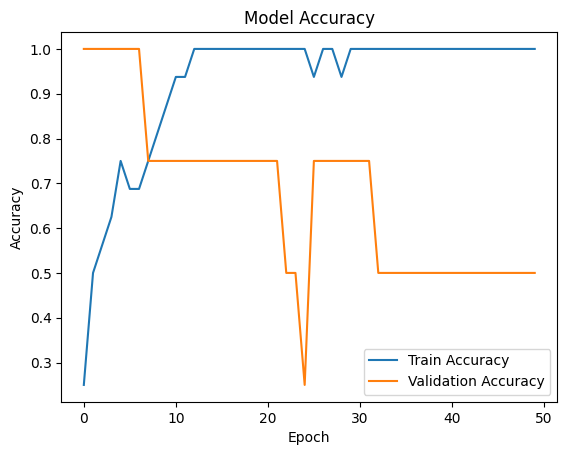

In [ ]:
# Build model
def build_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    return model

# Train model
model = build_model((X_train.shape[1], X_train.shape[2]))
history = model.fit(X_train, y_train,
                   epochs=50,
                   batch_size=32,
                   validation_data=(X_val, y_val),
                   verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [ ]:
# Prediction function with match info
def predict_winner(model, match_data, match_info=None):
    match_data_processed = scaler.transform(match_data.reshape(-1, match_data.shape[-1])).reshape(match_data.shape)
    home_win_prob = model.predict(match_data_processed[-1:])[0][0]

    result = {
        'home_win_probability': home_win_prob,
        'away_win_probability': 1 - home_win_prob,
        'predicted_winner': 'home' if home_win_prob > 0.5 else 'away',
        'confidence': max(home_win_prob, 1 - home_win_prob)
    }

    if match_info is not None:
        result.update({
            'match_id': match_info['match_id'],
            'teams': f"{match_info['team_a']} vs {match_info['team_b']}",
            'last_timestamp': match_info['last_timestamp']
        })

    return result

In [ ]:
# Predict for all test matches and calculate accuracy
def evaluate_test_set(model, X_test, y_test, test_info):
    predictions = []
    correct = 0

    print("\nTEST SET PREDICTIONS:")
    print("="*100)
    print(f"{'Match ID':<10} {'Teams':<30} {'Actual':<10} {'Predicted':<10} {'Home Prob':<12} {'Away Prob':<12} {'Correct':<8}")
    print("-"*100)

    for i in range(len(X_test)):
        # Get match data and info
        match_data = X_test[i:i+1]
        info = test_info.iloc[i]
        actual = 'home' if y_test[i] == 1 else 'away'

        # Make prediction
        pred = predict_winner(model, match_data, info)
        predicted = pred['predicted_winner']
        is_correct = (actual == predicted)

        # Update accuracy count
        if is_correct:
            correct += 1

        # Store prediction details
        predictions.append({
            'match_id': info['match_id'],
            'teams': info['team_a'] + " vs " + info['team_b'],
            'actual': actual,
            'predicted': predicted,
            'home_prob': pred['home_win_probability'],
            'away_prob': pred['away_win_probability'],
            'correct': is_correct
        })

        # Print current prediction
        print(f"{info['match_id']:<10} {info['team_a'] + ' vs ' + info['team_b']:<30} "
              f"{actual.upper():<10} {predicted.upper():<10} "
              f"{pred['home_win_probability']:.2%}{'':<2} {pred['away_win_probability']:.2%}{'':<2} "
              f"{'✓' if is_correct else '✗':<8}")

    # Calculate and print overall accuracy
    accuracy = correct / len(X_test)
    print("="*100)
    print(f"\nTEST SET ACCURACY: {accuracy:.2%} ({correct} correct out of {len(X_test)} predictions)")
    print("="*100)

    return pd.DataFrame(predictions)

# Run evaluation on test set
test_results = evaluate_test_set(model, X_test, y_test, test_info)

# # You can also save the results to CSV if needed
# test_results.to_csv('test_set_predictions.csv', index=False)


TEST SET PREDICTIONS:
Match ID   Teams                          Actual     Predicted  Home Prob    Away Prob    Correct 
----------------------------------------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
59986667   Hejda SR, Vaclav vs Fiklik, Ondrej HOME       HOME       68.32%   31.68%   ✓       
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
59993685   Tuma, Miroslav vs Strnad, Jaroslav (1964) AWAY       AWAY       3.14%   96.86%   ✓       
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
59967279   Bohac, Martin vs Serak, Petr   AWAY       AWAY       2.06%   97.94%   ✓       
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
60001017   Garcia, Pablo vs Tejuelo, Jose A AWAY       AWAY       3.46%   96.54%   ✓       
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
59993605   Kanok, Jaromir vs Tacinec, Martin HOME       HOME       91.62%   8.38%   ✓       
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
59986705   Vorisek, Tomas vs Cernota, Filip HOME       HOME       91.68%   8.